# Problemas de prueba de hipótesis

In [10]:
#Primero Que nada importamos lo que vallamos a necesitar
import scipy.stats as stats
import matplotlib.pyplot  as plt
import numpy as np
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Ejercicio 1

Usted es un nutricionista que investiga dos tipos diferentes de dietas para ver si existe una diferencia significativa en la pérdida de peso después de un mes. Eliges dos grupos aleatorios de personas; un grupo sigue la primera dieta y el otro sigue la segunda. Al final del mes, se registra la pérdida de peso (en kg) de cada persona:

| Diet 1 | Diet 2 |
|:-------|:-------|
| 2.0 | 3.0 |
| 2.5 | 3.2 |
| 3.0 | 3.1 |
| 2.8 | 2.9 |
| 2.3 | 2.8 |
| 2.7 | 3.0 |
| 2.5 | 3.2 |

Con estos datos se busca responder a la siguiente pregunta: ¿Existe una diferencia significativa en la pérdida de peso promedio entre las personas que siguieron la primera dieta y las que siguieron la segunda dieta?

Para sacar conclusiones, siga los siguientes puntos:

-Enunciar la hipótesis: hipótesis nula y alternativa.
-Realizar la prueba para comprobar la hipótesis. Puede utilizar la prueba t de Student.
-Analizar las conclusiones.

#### H0(Hipotesis Nula):
    LA PERDIDA DE PESO PROMEDIO ES IGUAL EN AMBAS DIETAS
#### H1(Hipotesis Alternativa):
    LA PERDIDA DE PESO PROMEDIO EN AMBAS DIETAS ES DIFERENTE

In [11]:
#Creamos Una Lista con los valores de ambas dietas
D1 = [2.0, 2.5, 3.0, 2.8, 2.3, 2.7, 2.5]
D2 = [3.0, 3.2, 3.1, 2.9, 2.8, 3.0, 3.2]
#Aplicamos "ttest_ind" de "scipy" y le pasamos ambas dietas
t_stat, p_val_t = stats.ttest_ind(D1, D2)
print(f"El t-value es: {t_stat}")
print(f"El p-value es: {p_val_t}")

El t-value es: -3.5383407969933938
El p-value es: 0.004083270191713912


### Conclusion:
    Como el p-value "0.004" es menor que el umbral "0.05" se rechaza la hipotesis nula

## ANOVA

**ANOVA** (*Analysis of Variance - Análisis de variación*) Es una técnica estadística utilizada para comparar las medidas de dos o más grupos. La idea detrás de ANOVA es descomponer la variabilidad total de los datos en dos componentes: variabilidad entre grupos y variabilidad dentro de los grupos:

- **Variabilidad entre grupos**: Esta variabilidad se refiere a las diferencias entre las medias del grupo. Si esta variabilidad es considerablemente mayor que la variabilidad dentro del grupo, podría ser una indicación de que al menos una de las medias del grupo es diferente.
- **Variabilidad dentro del grupo**: Esta variabilidad se refiere a la dispersión de los datos dentro de cada grupo. Si todos los grupos tienen una variabilidad similar, entonces cualquier diferencia notable en las medias de los grupos podría considerarse significativa.

Las hipótesis en ANOVA suelen incluir:

- **Hipótesis nula** ($H₀$): Las medias de todos los grupos son iguales.
- **Hipótesis alternativa** ($H₁$): Al menos una de las medias del grupo es diferente.

Si el resultado de la prueba ANOVA es significativo (por ejemplo, un valor p inferior a un umbral como 0,05), esto sugiere que al menos la media de un grupo es diferente.

## Ejercicio 2

Un agricultor decide probar tres tipos diferentes de fertilizantes para determinar si alguno es superior en términos de producción de maíz. El agricultor planta maíz en 15 parcelas idénticas y utiliza los tres fertilizantes (5 parcelas para cada tipo). Al final de la temporada mide el rendimiento de maíz (en kg) de cada parcela, con el siguiente resultado:

| Fertilizante 1 | Fertilizante 2 | Fertilizante 3 |
|:-------------|:-------------|:-------------|
| 20 | 22 | 24 |
| 21 | 21 | 23 |
| 20 | 23 | 22 |
| 19 | 22 | 23 |
| 20 | 21 | 24 |

Con estos datos busca responder la siguiente pregunta: ¿Existe una diferencia significativa en el rendimiento promedio del maíz entre los tres tipos de fertilizantes?

Para ayudarte, sigue los siguientes puntos:

-Enunciar la hipótesis: hipótesis nula y alternativa.
-Realizar la prueba ANOVA.
-Analizar las conclusiones.
-Si un fertilizante es mejor que otro, ¿cómo podemos saberlo?

#### H0(Hipotesis Nula)
    Las medias de rendimiento de los tres fertilizantes son iguales.
#### H1(Hipotesis Alternativa)
    Hay diferencia en la media de rendimiento en al menos uno de los fertilizantes.

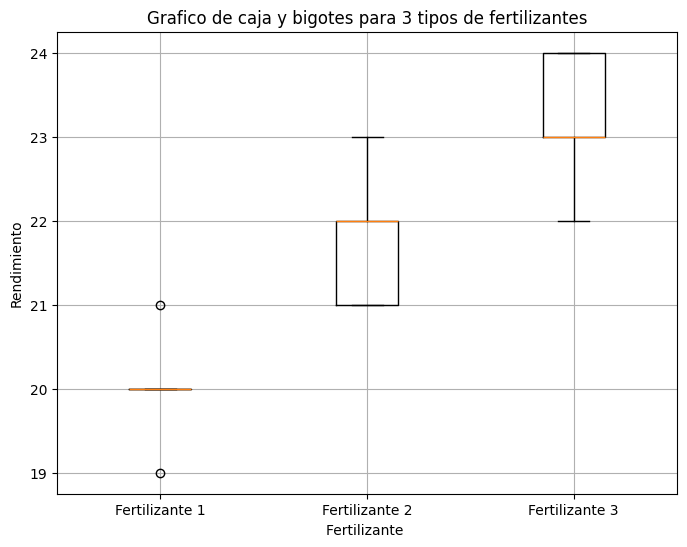

El valor de f-statistic es: 20.31579
El valor de p-value es: 0.00014


In [12]:
#Al igual que el ejercicio anterior creamos las listas con los fertilizantes
f1 = [20, 21, 20, 19, 20]
f2 = [22, 21, 23, 22, 21]
f3 = [24, 23, 22, 23, 24]
#Usamos la funcion f_oneway se scipy para sacar el anova pasandole los 3 grupos
f_stat, pvalue = stats.f_oneway(f1, f2, f3)

#Al igual que lo vimos en clases podemos intentar reflejarlo en un grafico de caja y bigotes
plt.figure(figsize=(8, 6))
plt.boxplot([f1, f2, f3], 
            tick_labels=['Fertilizante 1',  'Fertilizante 2',  'Fertilizante 3'])

plt.title('Grafico de caja y bigotes para 3 tipos de fertilizantes')
plt.ylabel('Rendimiento')
plt.xlabel('Fertilizante ')

plt.grid(True)
plt.show()
print("El valor de f-statistic es:",  round(f_stat, 5))
print("El valor de p-value es:",  round(pvalue, 5))

In [13]:
#Para responder a la interrogante de "Si un fertilizante es mejor que otro,  ¿cómo podemos saberlo?" 
#Podemos usar "TUKEY" de "statsmodels.stats.multicomp" para comparar las posibles combinaciones de grupos:
#Creamos un dataframe y le pasamos los fertilizantes pero juntos en una sola lista le asignamos la key "score"
#Y a las columnas "group" luego el parametro "repeats" va a ser el numero de elementos de cada grupo,  basicamente va
#a "Picar" la lista que le pasamos de 5 en 5 como estaba originalmente antes.
df = pd.DataFrame({'score': [20, 21, 20, 19, 20, 
                            22, 21, 23, 22, 21, 
                            24, 23, 22, 23, 24], 
                   'group': np.repeat(['Fertilizante 1',  'Fertilizante 2',  'Fertilizante 3'], repeats = 5)}) 
#Luego usamos pairwise_tukeyhsd de "statsmodels.stats.multicomp" y le pasamos los "scores",  los "group" y el umbral "alpha" 
tukey = pairwise_tukeyhsd(endog = df['score'], 
                          groups = df['group'], 
                          alpha = 0.05)
print(tukey)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1         group2     meandiff p-adj  lower  upper  reject
------------------------------------------------------------------
Fertilizante 1 Fertilizante 2      1.8 0.0099 0.4572 3.1428   True
Fertilizante 1 Fertilizante 3      3.2 0.0001 1.8572 4.5428   True
Fertilizante 2 Fertilizante 3      1.4 0.0409 0.0572 2.7428   True
------------------------------------------------------------------


### Conclusiones

    1)En el analizis anova Como el p-value es menor al alpha rechazamos la hipotesis nula,es decir, al menos uno de los fertilizantes produce un rendimiento promedio diferente.
    
    2)Mientras que en el analizis tukey todas las comparaciones nos tieron rechazado, es decir, un p-value < 0,05 en todos los casos haciendo que cada fertilizante sea diferente entre si.